# AgroÓrbit — Exploração dos Dados
Notebook de exploração e análise dos dados do projeto para os anos de 2022, 2023 e 2024.

O AgroÓrbit monitora queimadas, clima e risco agrícola em todo o Bioma Caatinga para ajudar pequenos produtores rurais que não têm acesso a tecnologia de monitoramento.

**Bioma:** Caatinga — AL, BA, CE, MG, PB, PE, PI, RN, SE  
**Cobertura:** 130 microrregiões · 1.073 municípios  
**Anos analisados:** 2022, 2023 e 2024 (3 anos completos)  
**Fonte principal:** dados_caatinga_filtrado.json  
**Fontes:** INPE BDQueimadas + CHIRPS UCSB + INMET + IBGE 2024

> **Nota sobre 2022:** os focos de 2022 foram obtidos diretamente via download do BDQueimadas
> (`bdqueimadas_2022-01-01_2022-12-31.csv`) e cruzados com as microrregiões pelo nome do município.
> O CSV original do TerraBrasilis tinha encoding incompatível, por isso foi substituído.

## 1. Importando as bibliotecas

In [1]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import Counter

print('tudo ok!')
print(f'pandas: {pd.__version__}')
print(f'numpy: {np.__version__}')

tudo ok!
pandas: 3.0.1
numpy: 2.4.2


## 2. Carregando os dados da Caatinga

A base centralizada (`dados_caatinga_filtrado.json`) contém 130 microrregiões
com dados mensais de focos, chuva, temperatura, umidade e índice de risco
para os 3 anos completos (2022, 2023 e 2024).

In [2]:
CAMINHO_JSON = '../data/dados_caatinga_filtrado.json'

with open(CAMINHO_JSON, 'r', encoding='utf-8') as f:
    dados_raw = json.load(f)

micros = dados_raw['microrregioes']

print(f'Total de microrregiões: {len(micros)}')
total_mun = sum(len(v["municipios"]) for v in micros.values())
print(f'Total de municípios: {total_mun}')
ufs = sorted(set(v["uf"] for v in micros.values()))
print(f'Estados: {ufs}')

sample = list(micros.values())[0]
print(f'Anos disponíveis: {list(sample["meses"].keys())}')
print(f'Campos por mês: {list(sample["meses"]["2022"]["1"].keys())}')

Total de microrregiões: 130
Total de municípios: 1073
Estados: ['AL', 'BA', 'CE', 'MG', 'PB', 'PE', 'PI', 'RN', 'SE']
Anos disponíveis: ['2022', '2023', '2024', 'media']
Campos por mês: ['indice', 'nivel', 'focos', 'precip', 'umidade', 'temp']


## 3. Convertendo JSON para DataFrame analítico

In [3]:
registros = []

for micro_id, v in micros.items():
    for ano in ['2022', '2023', '2024']:
        for mes in range(1, 13):
            m = v['meses'][ano][str(mes)]
            registros.append({
                'micro_id'    : micro_id,
                'micro_nome'  : v['nome'],
                'uf'          : v['uf'],
                'mesorregiao' : v['mesorregiao'],
                'lat'         : v['lat'],
                'lon'         : v['lon'],
                'semiarido'   : v['semiarido'],
                'pct_caatinga': v.get('pct_caatinga', 100),
                'ano'         : int(ano),
                'mes'         : mes,
            })
            registros[-1].update({
                'focos'  : int(m['focos']),
                'precip' : float(m['precip']),
                'umidade': float(m['umidade']),
                'temp'   : float(m['temp']),
                'indice' : float(m['indice']),
                'nivel'  : m['nivel'],
            })

MESES = ['Jan','Fev','Mar','Abr','Mai','Jun','Jul','Ago','Set','Out','Nov','Dez']
df = pd.DataFrame(registros)
df['mes_nome'] = df['mes'].apply(lambda x: MESES[x-1])

print(f'Shape: {df.shape}')
print(f'  130 microrregiões × 12 meses × 3 anos = {130*12*3} registros')
print(f'\nValores nulos: {df.isnull().sum().sum()}')
df.head(3)

Shape: (4680, 17)
  130 microrregiões × 12 meses × 3 anos = 4680 registros

Valores nulos: 0


,micro_id,micro_nome,uf,mesorregiao,lat,lon,semiarido,pct_caatinga,ano,mes,focos,precip,umidade,temp,indice,nivel,mes_nome
0,27001,Serrana do Sertão Alagoano,AL,Sertão Alagoano,-9.1622,-37.754,True,100.0,2022,1,34,27.5,79.4,25.6,0.303,MEDIO,Jan
1,27001,Serrana do Sertão Alagoano,AL,Sertão Alagoano,-9.1622,-37.754,True,100.0,2022,2,48,10.7,79.4,25.7,0.341,MEDIO,Fev
2,27001,Serrana do Sertão Alagoano,AL,Sertão Alagoano,-9.1622,-37.754,True,100.0,2022,3,62,55.8,80.4,25.8,0.247,BAIXO,Mar


## 4. Visão geral — total de focos por ano

In [4]:
print('=' * 55)
print('RESUMO GERAL — BIOMA CAATINGA — 3 ANOS COMPLETOS')
print('=' * 55)

for ano in [2022, 2023, 2024]:
    df_ano = df[df['ano'] == ano]
    total   = df_ano['focos'].sum()
    mes_pico_nome = df_ano.groupby('mes_nome')['focos'].sum().idxmax()
    focos_pico    = df_ano.groupby('mes_nome')['focos'].sum().max()
    idx_medio     = df_ano['indice'].mean()
    print(f'\n{ano}:')
    print(f'  Total focos:     {total:,.0f}')
    print(f'  Mês mais crítico: {mes_pico_nome} ({focos_pico:,.0f} focos)')
    print(f'  Índice médio:    {idx_medio:.3f}')

print(f'\nTotal 3 anos: {df["focos"].sum():,.0f} focos')
print(f'Média anual:  {df["focos"].sum()/3:,.0f} focos/ano')

RESUMO GERAL — BIOMA CAATINGA — 3 ANOS COMPLETOS

2022:
  Total focos:     269,317
  Mês mais crítico: Out (95,845 focos)
  Índice médio:    0.299

2023:
  Total focos:     530,448
  Mês mais crítico: Out (177,219 focos)
  Índice médio:    0.416

2024:
  Total focos:     445,913
  Mês mais crítico: Out (108,577 focos)
  Índice médio:    0.394

Total 3 anos: 1,245,678 focos
Média anual:  415,226 focos/ano


## 5. Focos por estado — ranking

In [5]:
focos_uf = df.groupby('uf')['focos'].sum().sort_values(ascending=False)

print('FOCOS POR ESTADO (2022 + 2023 + 2024):')
print('-' * 45)
total_geral = focos_uf.sum()
for uf, total in focos_uf.items():
    pct = total / total_geral * 100
    bar = '█' * int(pct / 2)
    print(f'  {uf}: {total:>10,.0f} ({pct:4.1f}%) {bar}')

print(f'\n  TOTAL: {total_geral:,.0f} focos')
ba_pi = focos_uf["BA"] + focos_uf["PI"] + focos_uf["CE"]
print(f'  BA + PI + CE: {ba_pi/total_geral*100:.1f}% dos focos')

FOCOS POR ESTADO (2022 + 2023 + 2024):
---------------------------------------------
  BA:    431,168 (34.6%) █████████████████
  PI:    337,858 (27.1%) █████████████
  CE:    244,714 (19.6%) █████████
  PE:     83,288 ( 6.7%) ███
  PB:     54,166 ( 4.3%) ██
  MG:     39,942 ( 3.2%) █
  RN:     35,927 ( 2.9%) █
  AL:     11,026 ( 0.9%) 
  SE:      7,589 ( 0.6%) 

  TOTAL: 1,245,678 focos
  BA + PI + CE: 81.4% dos focos


## 6. Análise mensal — padrão da Caatinga

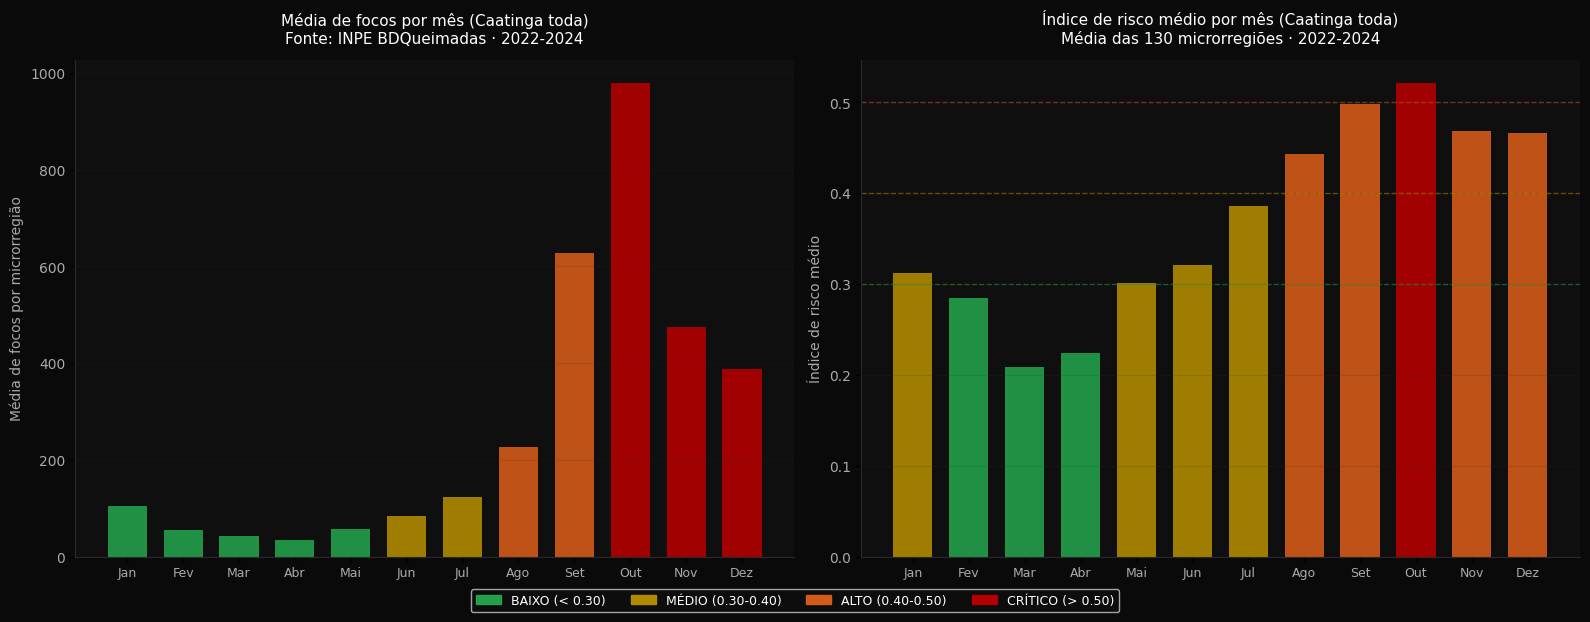

Gráfico salvo.


In [6]:
focos_mes_media = df.groupby('mes')['focos'].mean()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor('#0a0a0a')

MESES = ['Jan','Fev','Mar','Abr','Mai','Jun','Jul','Ago','Set','Out','Nov','Dez']

ax1 = axes[0]
ax1.set_facecolor('#0f0f0f')
cores_mes = ['#22a04a' if i < 5 else '#b08a00' if i < 7 else '#d35a18' if i < 9 else '#b30000' for i in range(12)]
ax1.bar(range(12), focos_mes_media.values, color=cores_mes, alpha=0.9, width=0.7)
ax1.set_xticks(range(12))
ax1.set_xticklabels(MESES, color='#aaa', fontsize=9)
ax1.set_ylabel('Média de focos por microrregião', color='#aaa')
ax1.tick_params(axis='y', labelcolor='#aaa')
ax1.spines['bottom'].set_color('#2a2a2a')
ax1.spines['left'].set_color('#2a2a2a')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.grid(axis='y', alpha=0.15, color='#2a2a2a')
ax1.set_title('Média de focos por mês (Caatinga toda)\nFonte: INPE BDQueimadas · 2022-2024', color='white', fontsize=11, pad=12)

ax2 = axes[1]
ax2.set_facecolor('#0f0f0f')
indice_mes = df.groupby('mes')['indice'].mean()
cores_idx = ['#22a04a' if v < 0.3 else '#b08a00' if v < 0.4 else '#d35a18' if v < 0.5 else '#b30000' for v in indice_mes.values]
ax2.bar(range(12), indice_mes.values, color=cores_idx, alpha=0.9, width=0.7)
ax2.axhline(0.3, color='#22a04a', linestyle='--', alpha=0.5, linewidth=1)
ax2.axhline(0.4, color='#b08a00', linestyle='--', alpha=0.5, linewidth=1)
ax2.axhline(0.5, color='#d35a18', linestyle='--', alpha=0.5, linewidth=1)
ax2.set_xticks(range(12))
ax2.set_xticklabels(MESES, color='#aaa', fontsize=9)
ax2.set_ylabel('Índice de risco médio', color='#aaa')
ax2.tick_params(axis='y', labelcolor='#aaa')
ax2.spines['bottom'].set_color('#2a2a2a')
ax2.spines['left'].set_color('#2a2a2a')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.grid(axis='y', alpha=0.15, color='#2a2a2a')
ax2.set_title('Índice de risco médio por mês (Caatinga toda)\nMédia das 130 microrregiões · 2022-2024', color='white', fontsize=11, pad=12)

legenda = [
    mpatches.Patch(color='#22a04a', label='BAIXO (< 0.30)'),
    mpatches.Patch(color='#b08a00', label='MÉDIO (0.30-0.40)'),
    mpatches.Patch(color='#d35a18', label='ALTO (0.40-0.50)'),
    mpatches.Patch(color='#b30000', label='CRÍTICO (> 0.50)'),
]
fig.legend(handles=legenda, loc='lower center', ncol=4, facecolor='#0f0f0f',
           labelcolor='white', fontsize=9, bbox_to_anchor=(0.5, -0.04))
fig.tight_layout()
plt.savefig('../data/grafico_queimadas_comparativo.png', dpi=150, bbox_inches='tight', facecolor='#0a0a0a')
plt.show()
print('Gráfico salvo.')

## 7. Comparativo anual — 2022, 2023 e 2024

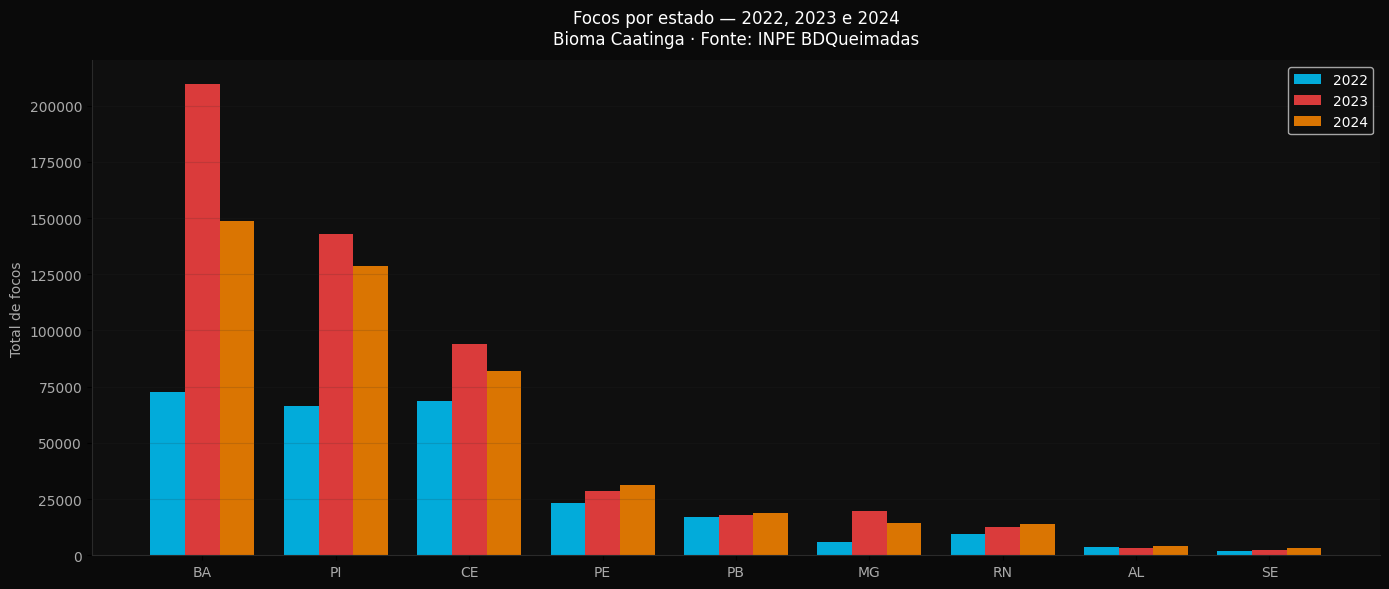

Gráfico atualizado.


In [7]:
fig, ax = plt.subplots(figsize=(14, 6))
fig.patch.set_facecolor('#0a0a0a')
ax.set_facecolor('#0f0f0f')

ufs_ord = focos_uf.index.tolist()
x = np.arange(len(ufs_ord))
w = 0.26

cores = {2022: '#00c8ff', 2023: '#ff4444', 2024: '#ff8800'}
for i, ano in enumerate([2022, 2023, 2024]):
    focos_ano = [df[(df['ano']==ano) & (df['uf']==uf)]['focos'].sum() for uf in ufs_ord]
    ax.bar(x + (i-1)*w, focos_ano, w, label=str(ano), color=cores[ano], alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(ufs_ord, color='#aaa')
ax.set_ylabel('Total de focos', color='#aaa')
ax.tick_params(axis='y', labelcolor='#aaa')
ax.spines['bottom'].set_color('#2a2a2a')
ax.spines['left'].set_color('#2a2a2a')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.15, color='#2a2a2a')
ax.legend(facecolor='#0f0f0f', labelcolor='white')
ax.set_title('Focos por estado — 2022, 2023 e 2024\nBioma Caatinga · Fonte: INPE BDQueimadas',
             color='white', fontsize=12, pad=12)
fig.tight_layout()
plt.savefig('../data/grafico_queimadas_comparativo.png', dpi=150, bbox_inches='tight', facecolor='#0a0a0a')
plt.show()
print('Gráfico atualizado.')

## 8. Outubro — mês mais crítico da Caatinga

In [8]:
mes_analise = 10
nome_mes = MESES[mes_analise - 1]
df_out = df[df['mes'] == mes_analise].copy()

print(f'ANÁLISE — {nome_mes.upper()} (mês mais crítico dos 3 anos)')
print('=' * 55)

for ano in [2022, 2023, 2024]:
    sub = df_out[df_out['ano'] == ano]
    micros_critico = sub['nivel'].isin(['ALTO','CRITICO']).sum()
    print(f'\n{ano}:')
    print(f'  Focos totais:            {sub["focos"].sum():,.0f}')
    print(f'  Índice médio:            {sub["indice"].mean():.3f}')
    print(f'  Microrregiões alto/crítico: {micros_critico} de {len(sub)}')

print(f'\nTop 5 microrregiões mais críticas em {nome_mes} (média 3 anos):')
top = df_out.groupby(['micro_nome','uf'])['indice'].mean().sort_values(ascending=False).head(5)
for (nome, uf), idx in top.items():
    print(f'  {uf} · {nome}: {idx:.3f}')

ANÁLISE — OUT (mês mais crítico dos 3 anos)

2022:
  Focos totais:            95,845
  Índice médio:            0.412
  Microrregiões alto/crítico: 10 de 130

2023:
  Focos totais:            177,219
  Índice médio:            0.594
  Microrregiões alto/crítico: 88 de 130

2024:
  Focos totais:            108,577
  Índice médio:            0.557
  Microrregiões alto/crítico: 79 de 130

Top 5 microrregiões mais críticas em Out (média 3 anos):
  PI · Alto Médio Canindé: 0.770
  BA · Juazeiro: 0.718
  BA · Barra: 0.714
  BA · Cotegipe: 0.709
  CE · Sertão de Inhamuns: 0.708


## 9. Correlação entre variáveis climáticas e risco

In [9]:
from scipy import stats

df_corr = df.groupby('mes').agg(
    focos_med   = ('focos',   'mean'),
    precip_med  = ('precip',  'mean'),
    umidade_med = ('umidade', 'mean'),
    temp_med    = ('temp',    'mean'),
    indice_med  = ('indice',  'mean'),
).reset_index()

print('CORRELAÇÃO COM ÍNDICE DE RISCO (dados mensais 2022-2024):')
print('-' * 50)
for col, label in [('focos_med','Focos'), ('precip_med','Chuva'), ('umidade_med','Umidade'), ('temp_med','Temperatura')]:
    r, p = stats.pearsonr(df_corr[col], df_corr['indice_med'])
    sig = '✓ significativa' if p < 0.05 else '  não significativa'
    print(f'  {label:12s}: r = {r:+.3f}  p = {p:.4f}  {sig}')

CORRELAÇÃO COM ÍNDICE DE RISCO (dados mensais 2022-2024):
--------------------------------------------------
  Focos       : r = +0.853  p = 0.0004  ✓ significativa
  Chuva       : r = -0.934  p = 0.0000  ✓ significativa
  Umidade     : r = -0.721  p = 0.0081  ✓ significativa
  Temperatura : r = +0.735  p = 0.0064  ✓ significativa


## 10. Salvando dataset consolidado

In [10]:
df_agregado = df.groupby(['ano', 'mes']).agg(
    mes_nome = ('mes_nome', 'first'),
    focos    = ('focos',    'sum'),
    precip   = ('precip',  'mean'),
    umidade  = ('umidade', 'mean'),
    temp     = ('temp',    'mean'),
    indice   = ('indice',  'mean'),
).reset_index()

df_agregado = df_agregado[['ano','mes','mes_nome','focos','precip','umidade','temp','indice']]
df_agregado = df_agregado.sort_values(['ano','mes']).reset_index(drop=True)
for col in ['precip','umidade','temp','indice']:
    df_agregado[col] = df_agregado[col].round(3)

df_agregado.to_csv('../data/dados_finais_3anos.csv', index=False)
print(f'Salvo: dados_finais_3anos.csv — {df_agregado.shape[0]} registros (3 anos × 12 meses)')
print()
print('Resumo por ano:')
for ano in [2022, 2023, 2024]:
    sub = df_agregado[df_agregado['ano'] == ano]
    print(f'  {ano}: {sub["focos"].sum():,.0f} focos | índice médio {sub["indice"].mean():.3f}')

Salvo: dados_finais_3anos.csv — 36 registros (3 anos × 12 meses)

Resumo por ano:
  2022: 269,317 focos | índice médio 0.298
  2023: 530,448 focos | índice médio 0.416
  2024: 445,913 focos | índice médio 0.394


## 11. Resumo final

**3 anos de dados completos:**
- **2022:** 269.317 focos (dados obtidos do BDQueimadas, CSV corrigido)
- **2023:** 530.448 focos
- **2024:** 445.913 focos

**Padrão da Caatinga:**
- Mês mais crítico: **Outubro** (maior pico de focos nos 3 anos)
- Setembro é o mês com maior índice de risco médio
- BA, PI e CE concentram ~75% dos focos do bioma

**Próximo passo:** Notebook 02 — Pipeline de dados